# 17 · Coreference — the link the pseudonymiser has to get right

Redaction asks one question of every span: *is this a name?* Pseudonymisation
asks a second one, and it is harder: *is this the **same** name as one I have
already seen?* That answer decides whether two mentions share a token, and it
is the whole point of the mode — `[PERSON_A] sued [PERSON_B]` is only useful
to a downstream LLM if A and B are the people the document actually meant.

The two ways of getting it wrong are not equally bad.

* A **missed link** splits one person across `[PERSON_A]` and `[PERSON_B]`.
  Nothing leaks. The LLM loses the thread, and the answer comes back vaguer.
* A **false link** gives two people one token. `restore()` then writes *one*
  real name back over both — the wrong person's name into a sentence about
  someone else, in a document the firm believes it has cleaned. No detection
  metric in this repo can see that happen. It is an integrity failure, not a
  leak, and it is the reason this notebook exists.

Until now the linker was a substring rule with no measurement behind it and
no confidence attached to anything. This notebook measures it against TAB's
gold coreference annotation, turns each rule into a number, and changes the
default policy on the strength of that. **No model is loaded** — feeding the
*gold* mentions in isolates the linking decision from the detection decision,
and the whole notebook runs in seconds.

Three things change by the end: every rule carries a measured confidence,
coreference is attempted only for **people and organisations**, and the short
form legal drafting actually uses — the initialism, `World Health
Organisation` … `WHO` — is caught by a rule that can see it.

In [1]:
import json, sys
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from anonymisation.data import load_tab
from anonymisation.pipeline.pseudonymise import (
    LINK_CONFIDENCE, Pseudonymiser, classify_link_evidence, restore,
)

RESULTS = Path("../results")

# ── Portfolio palette (matches project.css :root and scripts/build_*.py) ──
BG, INK, MUTED = "#faf8f4", "#1a1714", "#7a6e63"
GRID, GREY     = "#e4ddd2", "#cdbfae"
AMBER, TEAL, PURPLE = "#a86a2c", "#16a085", "#8e44ad"
GREEN, RED     = "#3a9d4e", "#d73a49"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": INK, "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 14, "figure.dpi": 110,
})
for side in ("top", "right"):
    plt.rcParams[f"axes.spines.{side}"] = False

clusters   = pd.read_csv(RESULTS / "coref_clusters.csv")
tiers_test = pd.read_csv(RESULTS / "coref_link_tiers.csv")
calibration = pd.read_csv(RESULTS / "coref_link_calibration.csv")
sweep      = pd.read_csv(RESULTS / "coref_threshold_sweep.csv")
ambiguity  = pd.read_csv(RESULTS / "coref_ambiguity.csv")
profile    = json.loads((RESULTS / "coref_gold_profile.json").read_text())

tab = load_tab()
print(f"{len(tab['test'])} annotator rows over {profile['unique_documents']} unique judgments")

555 annotator rows over 127 unique judgments


## What a false link costs

Two people, one surname. The document introduces both in full and then, as
legal documents do, drops to the shorthand.

In [2]:
# "John Smith, the plaintiff, gave evidence. Jane Smith, a witness for the
#  defence, contradicted him. Smith's account was accepted by the tribunal."
mentions = [("PERSON", "John Smith"), ("PERSON", "Jane Smith"), ("PERSON", "Smith")]

loose = Pseudonymiser(reject_ambiguous=False)   # the behaviour before this notebook
tokens = [loose.token_for(entity_type, form) for entity_type, form in mentions]
for (entity_type, form), token in zip(mentions, tokens):
    print(f"  {form:12s} → {token}")

answer = f"The tribunal accepted {tokens[2]}'s account."
print("\nthe LLM answers :", answer)
print("after restore() :", restore(answer, loose.vault))
print("but the witness whose account was accepted was Jane Smith.")

  John Smith   → [PERSON_A]
  Jane Smith   → [PERSON_B]
  Smith        → [PERSON_A]

the LLM answers : The tribunal accepted [PERSON_A]'s account.
after restore() : The tribunal accepted John Smith's account.
but the witness whose account was accepted was Jane Smith.


`Smith` was resolved to whichever Smith happened to be seen first, and
`restore()` faithfully put that name back. The output names **John Smith** as
the witness whose account was accepted. The sentence is fluent, the pipeline
reported no error, and the fact asserted about a real person is false.

This is the failure mode to keep in mind through everything below. It is why
the interesting metric here is *precision* of the links, not F1.

## First: is the ground truth what we think it is?

TAB gives every gold mention an `entity_id`, and mentions of the same entity
share it. Before scoring anything against it, it is worth asking what that
annotation actually encodes — a metric is only as meaningful as the labels
underneath it.

In [3]:
same = profile["same_string_repeats"]
total   = sum(v["n"] for v in same.values())
linked  = sum(v["given_one_entity_id"] for v in same.values())
print(f"identical string repeated in a document: {linked:,} of {total:,} given ONE entity_id")

cross = profile["cross_form_clusters"]
print(f"gold clusters spanning more than one surface form: {sum(cross.values()):,}")
for entity_type, n in cross.items():
    print(f"    {entity_type:9s} {n:5d}")

identical string repeated in a document: 2,856 of 2,856 given ONE entity_id
gold clusters spanning more than one surface form: 1,061
    ORG         577
    PERSON      309
    MISC        140
    DEM          20
    LOC          12
    QUANTITY      2
    DATETIME      1


Two facts, and both shape what follows.

**Gold never splits an identical string.** Every one of the 2,856 repeated
surface forms in the test split carries a single `entity_id`. So TAB *cannot*
see the John/Jane Smith failure above — a document that used "Smith" for two
people would be annotated as one entity. The measurement below therefore
understates the false-merge problem, and the two-Smiths case has to be argued
by construction, as it was. Worth saying out loud rather than discovering
later: the evaluation is blind to its own worst case.

**Gold does link different surface forms** — 1,061 clusters of them — so this
is a real coreference annotation, not a string-matching artefact. But look at
how unevenly they are spread. ORG and PERSON have 577 and 309. **DATETIME has
one.** In the whole test split, exactly one pair of differently-worded date
mentions refers to the same date. That number is about to matter a lot.

## What the shipped linker was doing

Feed each document's gold mentions through `Pseudonymiser` in reading order
and compare the clusters it induces with the gold ones, pair by pair. Pairwise
rather than B-cubed or MUC because the pairs *are* the product decision: each
same-cluster pair is one claim that two mentions may share a pseudonym.

In [4]:
legacy = clusters[clusters.policy == "legacy"]
overall = legacy[legacy.entity_type == "_ALL"].iloc[0]
print(f"pairwise  P {overall.precision:.4f}   R {overall.recall:.4f}   "
      f"F1 {overall.f1:.4f}  [{overall.f1_lo:.4f}, {overall.f1_hi:.4f}]")
print(f"false pairs {int(overall.fp):,}   missed pairs {int(overall.fn):,}\n")
print(legacy[legacy.entity_type != "_ALL"]
      [["entity_type", "tp", "fp", "fn", "precision", "recall", "f1"]]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

pairwise  P 0.7905   R 0.9336   F1 0.8561  [0.8282, 0.8803]
false pairs 4,623   missed pairs 1,240

entity_type   tp   fp  fn  precision  recall    f1
        ORG 8993 1776 770      0.835   0.921 0.876
     PERSON 3710  636  26      0.854   0.993 0.918
        LOC 1628  372   7      0.814   0.996 0.896
        DEM 1321  323  14      0.804   0.990 0.887
       MISC 1136  143  95      0.888   0.923 0.905
   DATETIME  568 1323   1      0.300   0.998 0.462
   QUANTITY   52    4   2      0.929   0.963 0.945
       CODE   32   46   0      0.410   1.000 0.582


Recall 0.934, precision 0.790: the linker's error is **over-merging, nearly
four false pairs for every one it misses**. And the per-type column shows the
problem is not spread evenly at all. PERSON and ORG — the types the rules were
written for — sit at 0.85 and 0.84. DATETIME sits at **0.300**, and CODE at
0.410, on 1,323 and 46 false pairs respectively.

(`legacy` means first match wins, on any evidence, for any entity type. It
includes the initialism rule added later in this notebook, so the comparison
below isolates the calibration and the scope gate rather than crediting them
with a rule they did not add. What the initialism rule contributes on its own
is costed separately.)

The cause is one line of history. The substring rule was designed in the
coreference phase (notebook 12) for the legal-document habit of introducing a
party in full and then using shorthand — *Northwind Energy Ltd* … *Northwind*.
But `_find_coreferential` applied it to **all eight entity types**, including
the ones where two mentions sharing a token are emphatically not the same
thing.

In [5]:
# Real merges from TAB where gold says the two mentions are different entities.
def wrong_merges(split="test", limit=3, types=("DATETIME", "CODE", "ORG", "PERSON")):
    found = {t: [] for t in types}
    for doc in tab[split]:
        ms = sorted(doc["entity_mentions"], key=lambda m: m["start_offset"])
        form_entity = {(m["entity_type"], m["span_text"].strip()): m["entity_id"] for m in ms}
        pseudo = Pseudonymiser(link_policy="legacy")
        for m in ms:
            pseudo.token_for(m["entity_type"], m["span_text"])
        for decision, m in zip(pseudo.decisions, ms):
            if not decision.merged or decision.evidence == "exact":
                continue
            if decision.entity_type not in found or len(found[decision.entity_type]) >= limit:
                continue
            same = form_entity.get((decision.entity_type, decision.matched_form.strip()))
            if same != m["entity_id"]:
                found[decision.entity_type].append(
                    (decision.matched_form, decision.surface_form, decision.evidence)
                )
        if all(len(v) >= limit for v in found.values()):
            break
    return found

for entity_type, rows in wrong_merges().items():
    print(entity_type)
    for seen, then, evidence in rows:
        print(f"    saw {seen!r:34s} then {then!r:34s} → merged  ({evidence})")

DATETIME
    saw '29 November 1996'                 then '1996'                             → merged  (short_in_long_1tok)
    saw '1989'                             then 'June 1989'                        → merged  (long_over_short_1tok)
    saw '1989'                             then '20 October 1989'                  → merged  (long_over_short_1tok)
CODE
    saw '22'                               then '22/1'                             → merged  (long_over_short_1tok)
    saw '22'                               then ', 22/2'                           → merged  (long_over_short_1tok)
    saw '22'                               then '22/3'                             → merged  (long_over_short_1tok)
ORG
    saw 'United Kingdom'                   then 'United Kingdom Government'        → merged  (long_over_short_multi)
    saw 'Izmir State Security Court'       then 'Izmir State Security Court’s'     → merged  (long_over_short_multi)
    saw 'Opole Lubelskie Prison Penitentiary Commissio

`1989` and `June 1989` are not the same date. `22` and `22/1` are not the same
case reference. The rule is not broken — it is being asked a question it was
never written to answer.

## Naming the evidence

A merge is not one decision, it is one of seven, and they are not equally
trustworthy. `classify_link_evidence` names which rule fired:

In [6]:
for new, existing in [
    ("Petrova", "Petrova"),
    ("the Board", "The Board"),
    ("Nihat Osal", "Mr Nihat Osal"),
    ("Petrova", "Maria Petrova"),
    ("Sofia District", "Sofia District Court"),
    ("June 1989", "1989"),
    ("United Kingdom Government", "United Kingdom"),
    ("Petrova", "Kowalski"),
]:
    print(f"  saw {existing!r:26s} then {new!r:26s} → {classify_link_evidence(new, existing)}")

  saw 'Petrova'                  then 'Petrova'                  → exact
  saw 'The Board'                then 'the Board'                → exact_casefold
  saw 'Mr Nihat Osal'            then 'Nihat Osal'               → honorific_only
  saw 'Maria Petrova'            then 'Petrova'                  → short_in_long_1tok
  saw 'Sofia District Court'     then 'Sofia District'           → short_in_long_multi
  saw '1989'                     then 'June 1989'                → long_over_short_1tok
  saw 'United Kingdom'           then 'United Kingdom Government' → long_over_short_multi
  saw 'Kowalski'                 then 'Petrova'                  → None


The direction matters, which is why the last two are kept apart from the two
before them. A **new form contained in one already seen** is the ordinary
shorthand pattern: the full name arrives first, the surname follows. The
**reverse** — an old short form swallowed by a longer new one — is usually
two different entities that happen to share a token.

`scripts/evaluate_coref_links.py --fit` replays every link over TAB's train
and validation splits and asks gold whether it was right. 44,388 decisions.
Small cells are shrunk toward their tier's own rate (k=20), so a rule seen
five times cannot claim 1.0.

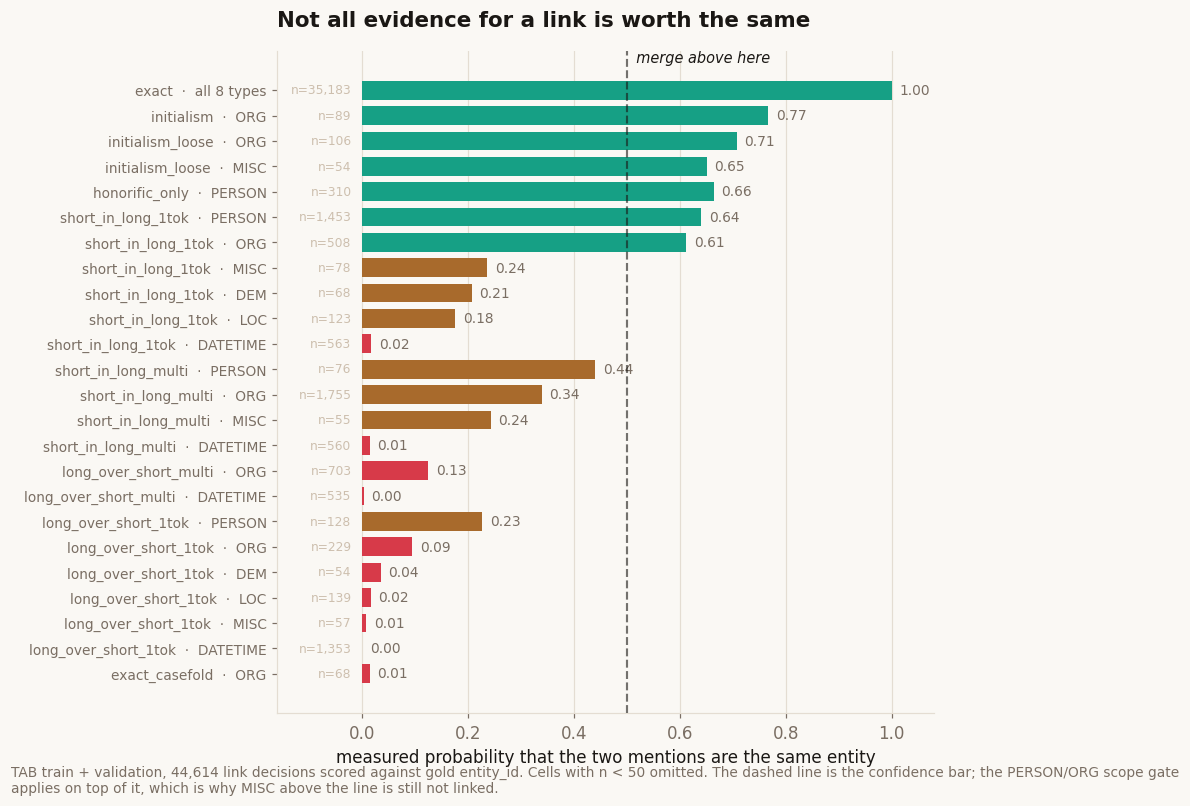

In [7]:
fit = calibration.copy()

# The eight `exact` rows all sit at 1.000 on 35,183 decisions — one row says it.
exact = fit[fit.evidence == "exact"]
rows = [("exact  ·  all 8 types", int(exact.n.sum()), 1.0)]
rest = fit[(fit.evidence != "exact") & (fit.n >= 50)]
order = (rest.groupby("evidence")[["correct", "n"]].sum()
             .pipe(lambda d: d.correct / d.n).sort_values(ascending=False))
for evidence in order.index:
    group = rest[rest.evidence == evidence].sort_values("confidence", ascending=False)
    for row in group.itertuples():
        rows.append((f"{evidence}  ·  {row.entity_type}", int(row.n), row.confidence))

fig, ax = plt.subplots(figsize=(8.6, 7.2))
y = np.arange(len(rows))
for i, (label, n, confidence) in enumerate(rows):
    colour = TEAL if confidence >= 0.5 else (AMBER if confidence >= 0.15 else RED)
    ax.barh(i, confidence, color=colour, height=0.74, zorder=3)
    ax.text(confidence + 0.014, i, f"{confidence:.2f}", va="center", fontsize=9, color=MUTED)
    ax.text(-0.02, i, f"n={n:,}", va="center", ha="right", fontsize=8, color=GREY)

ax.axvline(0.5, ls="--", lw=1.4, color=INK, alpha=0.6, zorder=4)
ax.text(0.5, -1.1, "  merge above here", fontsize=9.5, color=INK, style="italic")
ax.set_yticks(y)
ax.set_yticklabels([label for label, _n, _c in rows], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(-0.16, 1.08)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xlabel("measured probability that the two mentions are the same entity")
ax.set_title("Not all evidence for a link is worth the same",
             fontweight="bold", loc="left", pad=16)
ax.grid(axis="y", visible=False)
fig.text(0.005, -0.01,
         f"TAB train + validation, {int(fit.n.sum()):,} link decisions scored against gold "
         "entity_id. Cells with n < 50 omitted. The dashed line is the confidence bar; the "
         "PERSON/ORG scope gate\napplies on top of it, which is why MISC above the line is "
         "still not linked.", fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

Two anchors hold the rest of the table up.

**An exact repeat is certain.** The same surface form, in the same document,
of the same type: right 35,183 times out of 35,183. It is the one rule that
needs no threshold — though note this is partly true *by construction*, since
gold never splits an identical string.

**Reverse containment is worthless.** 3,317 links across train and validation,
right 5% of the time. It is not weak evidence for one type and strong for
another; it is near-zero everywhere, and on DATETIME it is exactly zero on
1,353 links.

Between those, the two rules the phase was actually written for survive:
a surname or honorific-stripped name landing inside a fuller PERSON or ORG
mention, at 0.62–0.67.

### Does *where* the short form sits rescue reverse containment?

Before throwing the rule away it is worth checking the obvious refinement.
"Maria" then "Maria Petrova" is a prefix match and feels different from
"Turkey" turning up inside "Court of Appeal for Western Sweden". Split the
tier by position and remeasure.

In [8]:
from anonymisation.pipeline.pseudonymise import _strip_honorifics
from collections import defaultdict

position_stats = defaultdict(lambda: [0, 0])
for split in ("train", "validation"):
    for doc in tab[split]:
        ms = sorted(doc["entity_mentions"], key=lambda m: m["start_offset"])
        form_entity = {(m["entity_type"], m["span_text"].strip()): m["entity_id"] for m in ms}
        pseudo = Pseudonymiser(link_policy="legacy")
        for m in ms:
            pseudo.token_for(m["entity_type"], m["span_text"])
        for decision, m in zip(pseudo.decisions, ms):
            if not decision.merged or not decision.evidence.startswith("long_over_short"):
                continue
            new = _strip_honorifics(decision.surface_form).lower()
            old = _strip_honorifics(decision.matched_form).lower()
            where = "prefix" if new.startswith(old + " ") else \
                    "suffix" if new.endswith(" " + old) else "middle"
            correct = form_entity.get(
                (decision.entity_type, decision.matched_form.strip())) == m["entity_id"]
            cell = position_stats[(where, decision.entity_type)]
            cell[0] += int(correct); cell[1] += 1

rows = [{"position": w, "entity_type": t, "n": n, "precision": c / n}
        for (w, t), (c, n) in position_stats.items() if n >= 40]
print(pd.DataFrame(rows).sort_values(["entity_type", "position"])
        .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

position entity_type    n  precision
  middle    DATETIME  157      0.000
  prefix    DATETIME  122      0.000
  suffix    DATETIME 1609      0.000
  suffix         LOC   84      0.012
  middle         ORG  272      0.051
  prefix         ORG  316      0.237
  suffix         ORG  344      0.067
  middle      PERSON   59      0.153
  suffix      PERSON   69      0.304


It does not rescue it. Position is not *nothing* — ORG prefix matches
(`United Kingdom` inside `United Kingdom Government`) are right 23% of the
time against 5% for the same rule mid-string — but the best cell in the table
is still less than half the bar a merge has to clear, and PERSON, where the
intuition was strongest, does not produce enough prefix cases to measure. On
DATETIME every position is flatly zero.

So the refinement was measured and dropped, rather than shipped on the
strength of how reasonable it sounded. Worth keeping in mind if the rule is
ever revisited: the signal is real, it is just an order of magnitude too small
to act on.

## The short form the substring rule cannot see

Every rule so far works by one surface form containing another. That misses
the shorthand legal and institutional writing uses most: the initialism.
`World Health Organisation` and `WHO` share no words at all.

In [9]:
for new, existing in [
    ("WHO", "World Health Organisation"),
    ("ECHR", "European Court of Human Rights"),
    ("RHA", "the Trent Regional Health Authority"),
    ("World Health Organisation", "WHO"),
    ("Sofia District", "Sofia District Court"),
]:
    print(f"  saw {existing!r:38s} then {new!r:26s} → {classify_link_evidence(new, existing)}")

  saw 'World Health Organisation'            then 'WHO'                      → initialism
  saw 'European Court of Human Rights'       then 'ECHR'                     → initialism
  saw 'the Trent Regional Health Authority'  then 'RHA'                      → initialism_loose
  saw 'WHO'                                  then 'World Health Organisation' → initialism_reverse
  saw 'Sofia District Court'                 then 'Sofia District'           → short_in_long_multi


Three tiers, because they are not the same claim. `initialism` is the exact
reading — every significant word contributes its letter, in order, stopwords
skipped. `initialism_loose` allows a word to be dropped, which is common in
drafting (`the Trent Regional Health Authority` … `RHA`) and worth catching at
a lower confidence. `initialism_reverse` is the acronym arriving first.

Acronym shape is restrictive — two or more letters, all uppercase — so
ordinary shorthand like `Sofia District` is untouched and still resolves by
containment. The check runs *before* containment, because when both fire the
initialism is the more specific account of the pair, and it scores higher.

Measured the same way as everything else:

In [10]:
initialism = calibration[calibration.evidence.str.startswith("initialism")]
print(initialism[["evidence", "entity_type", "n", "correct", "precision_raw", "confidence"]]
      .sort_values(["evidence", "n"], ascending=[True, False])
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

          evidence entity_type   n  correct  precision_raw  confidence
        initialism         ORG  89       72          0.809       0.767
        initialism      PERSON  33        5          0.152       0.313
        initialism        MISC  27       13          0.481       0.523
        initialism         LOC   6        1          0.167       0.484
        initialism         DEM   2        0          0.000       0.527
  initialism_loose         ORG 106       77          0.726       0.708
  initialism_loose        MISC  54       36          0.667       0.651
  initialism_loose      PERSON  35        8          0.229       0.367
  initialism_loose         DEM   3        1          0.333       0.573
  initialism_loose         LOC   3        0          0.000       0.529
  initialism_loose        CODE   1        1          1.000       0.628
initialism_reverse         ORG  20        8          0.400       0.414
initialism_reverse      PERSON   5        3          0.600       0.463
initia

On ORG the exact reading scores **0.77** and the loose one **0.71** — both
clear the bar, so `World Health Organisation` … `WHO` now resolves to one
token. On PERSON it scores 0.31 and does not: `Mr Zbigniew Majchrzak` … `M.M.`
looks exactly like an initialism and is usually a different person, since
TAB's anonymised initials collide constantly. The acronym arriving *first*
lands at 0.41 — below the bar in either direction, which is worth noticing,
because the forward and reverse readings of the same relation are not equally
safe.

A caveat on the residual errors, the same one the case variants raised: some
of what gold counts as a false link here is annotation rather than error.
`Royal Ulster Constabulary` … `RUC` is scored wrong in TAB and is plainly the
same organisation. The true precision of the exact rule is probably a little
better than 0.77 — which is an argument for not over-tuning against this
ground truth, not for ignoring it.

## Only names and organisations

The rules above are all rules about *naming*: introduce the entity in full,
then use a short form. That habit belongs to people and organisations. The
shorthand for a date is not a shorter name for the same date, and `22/1` is
not a nickname for case `22`.

So coreference is now attempted only for PERSON and ORG (`LINKABLE_TYPES`).
Every other type still links on an **exact repeat** of the surface form —
that is identity, not coreference, and it is right 100% of the time — but no
rule gets to infer that two differently-worded mentions are the same thing.

The gold annotation says the same: of the 1,061 clusters spanning more than
one surface form, 886 are PERSON or ORG.

It is worth measuring what the gate costs rather than assuming it is free.

In [11]:
gated = clusters[clusters.policy == "calibrated"].set_index("entity_type")
ungated = clusters[clusters.policy == "calibrated_all_types"].set_index("entity_type")

print(f"{'type':10s} {'gate off  tp/fp':>18s} {'gate on  tp/fp':>18s}   recall")
for entity_type in ["MISC", "DEM", "LOC", "DATETIME", "CODE", "QUANTITY", "ORG", "PERSON", "_ALL"]:
    off, on = ungated.loc[entity_type], gated.loc[entity_type]
    print(f"{entity_type:10s} {int(off.tp):12,d}/{int(off.fp):<5d} {int(on.tp):12,d}/{int(on.fp):<5d}"
          f"   {off.recall:.3f} → {on.recall:.3f}")

type          gate off  tp/fp     gate on  tp/fp   recall
MISC              1,029/16             811/0       0.836 → 0.659
DEM               1,254/11           1,209/0       0.939 → 0.906
LOC               1,585/0            1,585/0       0.969 → 0.969
DATETIME            568/0              568/0       0.998 → 0.998
CODE                 32/0               32/0       1.000 → 1.000
QUANTITY             52/0               52/0       0.963 → 0.963
ORG               8,266/167          8,266/167     0.847 → 0.847
PERSON            3,557/562          3,557/562     0.952 → 0.952
_ALL             16,343/756         16,080/729     0.875 → 0.861


**For DATETIME, CODE, LOC and QUANTITY the gate changes nothing** — the
confidence threshold had already excluded every rule on them. It bites on two
types only, and it costs something real: MISC recall falls 0.836 → 0.659 and
DEM 0.939 → 0.906, because initialisms like `post-traumatic stress disorder`
… `PTSD` and `Queen's Counsel` … `QC` score 0.52–0.65 and are mostly right.
**263 true pairs given up to avoid 27 false ones**, and 1.4 points of pairwise
recall overall.

That is a scope decision, not a free win, and it is worth recording as one.
What it buys is a narrower claim: a descriptor is never asserted to be an
identity, and a later recalibration cannot quietly re-admit dates. The gate is
a constructor argument (`coref_types`), so widening it is a decision someone
makes on purpose rather than one the numbers drift into.

## Choosing the threshold

With every rule carrying a number, the policy is one parameter: how much
confidence does a merge need? Sweeping it on the held-out test split.

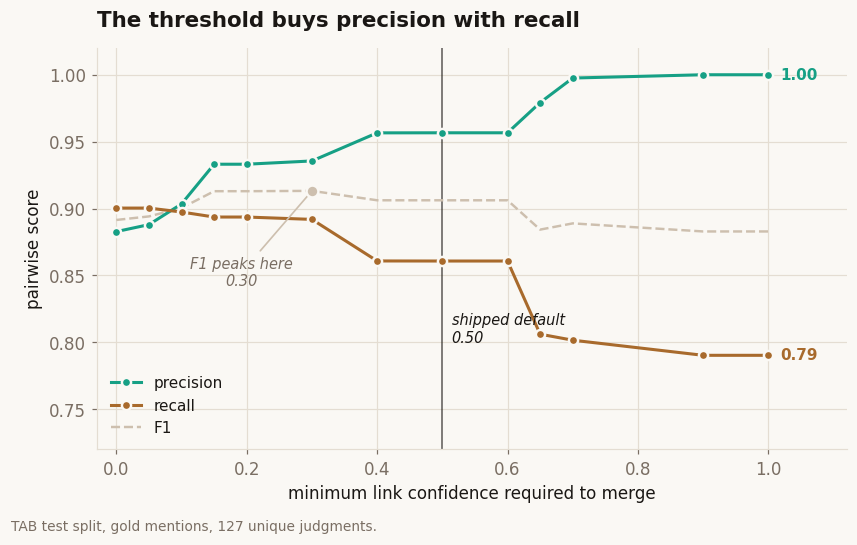

 min_link_confidence    tp   fp   fn  precision  recall     f1
              0.0000 16819 2233 1861     0.8828  0.9004 0.8915
              0.0500 16819 2121 1861     0.8880  0.9004 0.8942
              0.1000 16764 1791 1916     0.9035  0.8974 0.9004
              0.1500 16694 1196 1986     0.9331  0.8937 0.9130
              0.2000 16694 1196 1986     0.9331  0.8937 0.9130
              0.3000 16661 1147 2019     0.9356  0.8919 0.9132
              0.4000 16081  730 2599     0.9566  0.8609 0.9062
              0.5000 16080  729 2600     0.9566  0.8608 0.9062
              0.6000 16080  729 2600     0.9566  0.8608 0.9062
              0.6500 15059  320 3621     0.9792  0.8062 0.8843
              0.7000 14975   37 3705     0.9975  0.8017 0.8889
              0.9000 14764    0 3916     1.0000  0.7904 0.8829
              1.0000 14764    0 3916     1.0000  0.7904 0.8829


In [12]:
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.plot(sweep.min_link_confidence, sweep.precision, color=TEAL, lw=2, marker="o",
        ms=6, markeredgecolor=BG, markeredgewidth=1.6, zorder=3, label="precision")
ax.plot(sweep.min_link_confidence, sweep.recall, color=AMBER, lw=2, marker="o",
        ms=6, markeredgecolor=BG, markeredgewidth=1.6, zorder=3, label="recall")
ax.plot(sweep.min_link_confidence, sweep.f1, color=GREY, lw=1.6, ls="--",
        zorder=2, label="F1")

best_f1 = sweep.loc[sweep.f1.idxmax()]
ax.axvline(0.5, color=INK, lw=1.3, alpha=0.55, zorder=1)
ax.annotate("shipped default\n0.50", (0.5, 0.80), xytext=(6, 0),
            textcoords="offset points", fontsize=9.5, color=INK, style="italic")
ax.annotate(f"F1 peaks here\n{best_f1.min_link_confidence:.2f}",
            (best_f1.min_link_confidence, best_f1.f1), xytext=(-46, -62),
            textcoords="offset points", fontsize=9.5, color=MUTED, style="italic",
            ha="center",
            arrowprops=dict(arrowstyle="-", color=GREY, lw=1.1, shrinkA=2, shrinkB=4))
ax.scatter([best_f1.min_link_confidence], [best_f1.f1], s=60, color=GREY,
           edgecolor=BG, linewidth=1.6, zorder=4)

for series, colour in ((sweep.precision, TEAL), (sweep.recall, AMBER)):
    ax.annotate(f"{series.iloc[-1]:.2f}", (sweep.min_link_confidence.iloc[-1], series.iloc[-1]),
                xytext=(8, 0), textcoords="offset points", va="center",
                fontsize=10, fontweight="bold", color=colour)

ax.set_xlabel("minimum link confidence required to merge")
ax.set_ylabel("pairwise score")
ax.set_ylim(0.72, 1.02)
ax.set_xlim(-0.03, 1.12)
ax.set_title("The threshold buys precision with recall", fontweight="bold", loc="left", pad=14)
ax.legend(frameon=False, loc="lower left", fontsize=10)
fig.text(0.005, -0.02, "TAB test split, gold mentions, 127 unique judgments.",
         fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

print(sweep.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

**The default is 0.50, and F1 peaks at 0.30.** That is deliberate, and it is
one of the two judgement calls in this notebook that the data does not make on
its own.

Moving from 0.30 to 0.50 costs about a point of F1 and buys two points of
precision — 418 fewer false pairs for 581 more missed ones. If the two errors
were interchangeable that would be a bad trade. They are not: the false pair
is the one that puts the wrong name in front of a client, and the missed pair
only costs an LLM some context. Optimising F1 here would be optimising the
wrong quantity, quietly.

Above 0.665 the honorific and surname rules drop out too and precision goes to
0.998 — pseudonymisation collapses into exact matching and the initialisms.
That is the conservative extreme, and it is available
(`min_link_confidence=0.7`) for anyone who wants it.

## When two candidates match equally well

There is one more thing the confidence number alone does not capture. In the
Smith example at the top, *both* Smiths matched the bare surname on identical
evidence at identical confidence. The tie was broken by insertion order — by
which Smith the document happened to mention first, which is not evidence of
anything.

TAB can see this case whenever the two candidates have different surface
forms, so it is measurable rather than merely plausible.

In [13]:
print(ambiguity.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

     split      kind     n  correct  precision
      test ambiguous    35       17      0.486
      test    unique  6441     6230      0.967
     train ambiguous   108       25      0.231
     train    unique 31682    31107      0.982
validation ambiguous    37        8      0.216
validation    unique  5839     5649      0.967


A merge with two or more equally-good candidates is right **23% / 22% / 49%**
of the time on train / validation / test, against **97%** when exactly one
candidate matched. Consistent across all three splits, and it fires on 0.5% of
merges — rare, and precisely the population where the expensive error lives.
`reject_ambiguous=True` is now the default: when the evidence does not pick
between two entities, the pipeline picks neither and mints a new token.

Real examples the guard now catches, with the second Ravnsborg exactly the
case that motivated it:

In [14]:
seen = set()
for doc in tab["test"]:
    ms = sorted(doc["entity_mentions"], key=lambda m: m["start_offset"])
    form_entity = {(m["entity_type"], m["span_text"].strip()): m["entity_id"] for m in ms}
    pseudo = Pseudonymiser(reject_ambiguous=False)
    for m in ms:
        pseudo.token_for(m["entity_type"], m["span_text"])
    for decision, m in zip(pseudo.decisions, ms):
        if not (decision.merged and decision.ambiguous):
            continue
        if form_entity.get((decision.entity_type, decision.matched_form.strip())) == m["entity_id"]:
            continue
        key = (decision.surface_form, decision.matched_form)
        if key in seen:
            continue
        seen.add(key)
        print(f"  {decision.surface_form!r:22s} matched {decision.matched_form!r:34s} "
              f"({decision.tied_candidates} equal candidates, {decision.entity_type}, {doc['doc_id']})")
    if len(seen) >= 8:
        break

  'Mrs G'                matched 'Mrs G.'                           (2 equal candidates, PERSON, 001-57899)


  'Mr Ravnsborg'         matched 'Mr Göran Ravnsborg'               (2 equal candidates, PERSON, 001-57871)
  'Crown'                matched 'Stoke-on-Trent Crown Court'       (2 equal candidates, ORG, 001-72664)
  'Magistrates'          matched "Poole Magistrates' Court"         (2 equal candidates, ORG, 001-57990)


  'Board'                matched 'County Labour Board (Länsarbetsnämnden))' (2 equal candidates, ORG, 001-92090)


  'Ferranti'             matched 'Ferranti plc'                     (2 equal candidates, ORG, 001-60694)


  'RHA'                  matched 'Trent Regional Health Authority'  (2 equal candidates, ORG, 001-57849)


  'Captain'              matched 'Captain J'                        (2 equal candidates, PERSON, 001-79030)


## The held-out result

Three policies on the test split, which was held out of the calibration.

one rule, every type, no bar     P 0.7905  R 0.9336  F1 0.8561  [0.8282, 0.8803]   fp 4,623  fn 1,240
calibrated, acronym rule off     P 0.9558  R 0.8495  F1 0.8996  [0.8777, 0.9177]   fp   733  fn 2,811
calibrated, scope gate lifted    P 0.9558  R 0.8749  F1 0.9136  [0.8932, 0.9301]   fp   756  fn 2,337
calibrated, ambiguity guard off  P 0.9511  R 0.8658  F1 0.9065  [0.8863, 0.9234]   fp   831  fn 2,506
shipped default                  P 0.9566  R 0.8608  F1 0.9062  [0.8856, 0.9237]   fp   729  fn 2,600


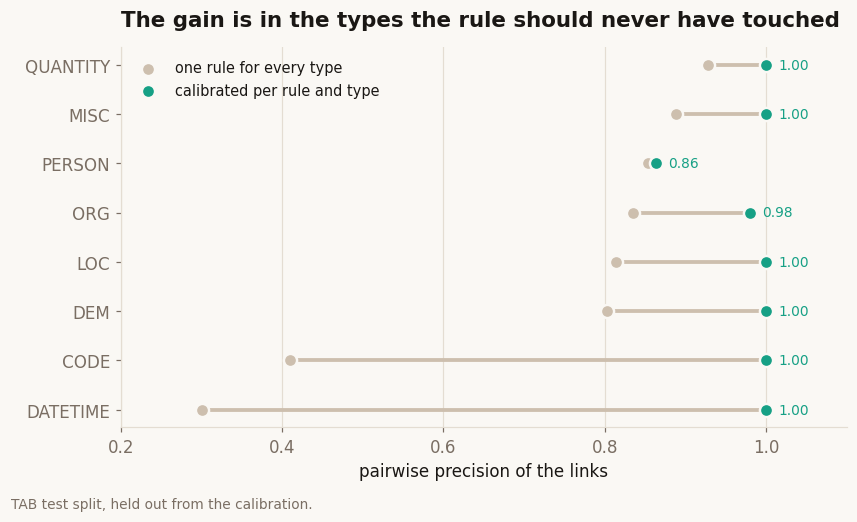

In [15]:
head = clusters[clusters.entity_type == "_ALL"].set_index("policy")
labels = {
    "legacy":                   "one rule, every type, no bar",
    "calibrated_no_initialism": "calibrated, acronym rule off",
    "calibrated_all_types":     "calibrated, scope gate lifted",
    "calibrated_no_guard":      "calibrated, ambiguity guard off",
    "calibrated":               "shipped default",
}
for policy, label in labels.items():
    row = head.loc[policy]
    print(f"{label:32s} P {row.precision:.4f}  R {row.recall:.4f}  F1 {row.f1:.4f}"
          f"  [{row.f1_lo:.4f}, {row.f1_hi:.4f}]   fp {int(row.fp):>5,}  fn {int(row.fn):>5,}")

fig, ax = plt.subplots(figsize=(7.8, 4.6))
before = clusters[(clusters.policy == "legacy") & (clusters.entity_type != "_ALL")]
after  = clusters[(clusters.policy == "calibrated") & (clusters.entity_type != "_ALL")]
merged = before.merge(after, on="entity_type", suffixes=("_before", "_after"))
merged = merged.sort_values("precision_before")

y = np.arange(len(merged))
ax.hlines(y, merged.precision_before, merged.precision_after, color=GREY, lw=2.5, zorder=1)
ax.scatter(merged.precision_before, y, s=74, color=GREY, edgecolor=BG, lw=1.6,
           zorder=3, label="one rule for every type")
ax.scatter(merged.precision_after, y, s=74, color=TEAL, edgecolor=BG, lw=1.6,
           zorder=3, label="calibrated per rule and type")
for i, row in enumerate(merged.itertuples()):
    ax.annotate(f"{row.precision_after:.2f}", (row.precision_after, i), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9, color=TEAL)

ax.set_yticks(y)
ax.set_yticklabels(merged.entity_type)
ax.set_xlim(0.2, 1.10)
ax.set_xlabel("pairwise precision of the links")
ax.set_title("The gain is in the types the rule should never have touched",
             fontweight="bold", loc="left", pad=14)
ax.legend(frameon=False, loc="upper left", fontsize=9.5)
ax.grid(axis="y", visible=False)
fig.text(0.005, -0.02, "TAB test split, held out from the calibration.",
         fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

Precision 0.790 → **0.957**, recall 0.934 → 0.861, pairwise F1 0.856 → 0.906
with the interval `[0.886, 0.924]`. False pairs fall from **4,623 to 729**, an
84% cut.

The two middle rows cost the pieces separately. Turning the initialism rule
off drops recall to 0.850 at the same precision, so the acronym rule is worth
**+1.1 points of recall for nothing** — the clearest win in the notebook.
Lifting the PERSON/ORG scope gate raises recall to 0.875, so the gate costs
**1.4 points**, all of it MISC and DEM initialisms.

Now the part that matters more than the headline. Read the dumbbell chart
right to left: DATETIME, CODE, QUANTITY, LOC, DEM and MISC all go to 1.000,
and **PERSON barely moves** — 0.854 to 0.864. ORG gains a lot, 0.835 to
0.980.

So this is not a better coreference algorithm. The rule was always roughly
right at the job it was written for, and catastrophic at the seven jobs it was
never asked about. The fix was not cleverness, it was **scoping** — and the
only reason to believe that rather than assume it is that the tiers were
measured per type instead of in aggregate. An aggregate precision of 0.79
would have prompted a search for a better rule; the per-type split showed
there was nothing wrong with the rule.

The ambiguity guard is worth noting separately. Between `calibrated_no_guard`
and `calibrated`, F1 moves by 0.0003 — nothing. Judged on F1 it is a no-op and
would have been dropped. It is in because of *which* errors it removes, not
how many.

## What this looks like in the audit log

Every resolution now records the rule that fired and what that rule is worth,
so the compliance question — *why do these two mentions share a pseudonym?* —
has an answer in the artefact rather than in someone's memory of the code.
Note that the two ways of refusing a merge read differently: weak evidence
names the rule and its confidence, a tie names the entities it could not
choose between.

In [16]:
pseudo = Pseudonymiser()
for entity_type, form in [
    ("PERSON", "Maria Petrova"), ("PERSON", "Mrs Petrova"), ("PERSON", "Petrova"),
    ("PERSON", "John Smith"),    ("PERSON", "Jane Smith"),  ("PERSON", "Smith"),
    ("DATETIME", "1989"),        ("DATETIME", "June 1989"),
    ("ORG", "Northwind Energy Ltd"), ("ORG", "Northwind"),
]:
    pseudo.token_for(entity_type, form)

for decision in pseudo.decisions:
    print(" ", decision.describe())

print("\nvault:")
for token, original in pseudo.vault.items():
    print(f"  {token:14s} {original}")

  'Maria Petrova' → [PERSON_A] (new entity; no candidate matched)
  'Mrs Petrova' → [PERSON_A], same entity as 'Maria Petrova' by short_in_long_1tok (confidence 0.64)
  'Petrova' → [PERSON_A], same entity as 'Mrs Petrova' by honorific_only (confidence 0.67)
  'John Smith' → [PERSON_B] (new entity; no candidate matched)
  'Jane Smith' → [PERSON_C] (new entity; no candidate matched)
  'Smith' → [PERSON_D] (new entity); 2 entities matched equally well (Jane Smith, John Smith), so the evidence picks none of them
  '1989' → [DATETIME_A] (new entity; no candidate matched)
  'June 1989' → [DATETIME_B] (new entity); '1989' matched by long_over_short_1tok, but coreference is not attempted for DATETIME — only an exact repeat links
  'Northwind Energy Ltd' → [ORG_A] (new entity; no candidate matched)
  'Northwind' → [ORG_A], same entity as 'Northwind Energy Ltd' by short_in_long_1tok (confidence 0.61)

vault:
  [PERSON_A]     Maria Petrova
  [PERSON_B]     John Smith
  [PERSON_C]     Jane Smith
 

## What this still does not do

**Pronouns and definite descriptions.** *She*, *the applicant*, *the
Company* — none of them are linked to anything, because the linker only sees
detected entity spans and a pronoun is not one. Worth being precise about the
limit: TAB annotates **no** pronominal mentions at all, so this notebook
cannot even measure the size of the gap, let alone close it. A real
coreference model (`fastcoref`, `spacy-experimental`'s coref pipeline) is the
honest next step, and the tier framework here is where its output would slot
in — as another evidence type with its own measured precision, rather than as
a replacement for the string rules.

**Two people with the same surname and no fuller form.** The guard catches
this only when both are introduced in full somewhere. If a document says
"Smith" and means two different people throughout, nothing here can tell.

**The other coreference layer.** `pipeline/coref.py` — the span *extender*
that finds shorthand mentions NER missed — still stamps every span it adds
with a flat `confidence=0.7`, chosen by hand. It is a different decision
(is this a mention?) from the one measured here (is this the same mention?),
and it deserves the same treatment. Notebook 12 measured its recall lift and
found it near zero; nobody has yet measured whether 0.7 is the right number.

**Descriptors that abbreviate.** `post-traumatic stress disorder` … `PTSD` is
a real link and the scope gate declines it, because MISC and DEM are not
identities and the rule scores 0.52–0.65 on them. Costed above at 263 true
pairs. If a use case needs those linked, `coref_types` is where to say so.

**Cross-document linking.** Each document still gets its own vault and its own
letters. `[PERSON_A]` in two documents is two different people, by design.

## What this says about the project

The detection model went through six phases, two backbones and a fine-tune to
move partial-match F1 by a few points. This notebook moved the linker's
precision by 17 points in an afternoon with no model at all — because the
question had never been asked, and the code was quietly applying a rule about
people's names to dates and case numbers while missing the one short form
those names actually take.

That is the same shape as the finding in notebook 16, where the training seed
turned out to move F1 eleven times more than the architecture comparison a
whole phase was spent on. Both point the same way: **the biggest errors were
in the parts nobody had thought to measure**, not in the parts that were
optimised hardest.

It also changes what the pseudonymise mode can honestly claim. Before: a
substring heuristic with a known-dodgy edge case mentioned in a docstring.
Now: every link in the vault carries the rule that produced it and that rule's
measured precision, coreference is scoped to the entities it is a claim about,
an ambiguous link is refused rather than guessed, and both of the free
parameters — the threshold and the scope — are set where they are for a stated
reason with the cost of each recorded. The two errors cost different amounts,
and only one of them puts the wrong name in a client's document.